# extraction
 $\rightarrow$ **passage du spectre 2D $\rightarrow$ 1D (tracé, extraction, calibration, réponse instrumentale, normalisation)**



## définition des répertoires et fichiers

In [1]:
# on define frames locations
#CAPTURE_DIR = 'data/20240710_10lac_chcyg_tcrb_m16_m57_betalyr_vega_alphacep/'
#CAPTURE_DIR = 'data/20250822_v1296Aql_altair_Tcrb_rsOph/'
#CAPTURE_DIR='data/20161200_CHATEAU_TIPE/'
#CAPTURE_DIR='data/20250807_deneb_ruchbah_gamcas/'
#CAPTURE_DIR='../../../CAPTURES/20251102_cxdra_v1770cyg_deneb/'
CAPTURE_DIR = '../../../CAPTURES/20260224_m97_merak_procyon/'

### hérité de la phase de pré-traitement
OUTPUT_CALIB = 'master_calib.fits'
OUTPUT_SCIENCE = 'master_science.fits'
OUTPUT_RESPONSE = 'response_spec.fits'

### Observatory location
# CALC
OBS_LATITUDE = 47.89
OBS_LONGITUDE = -1.50
ALTITUDE: 50

#OHP
#OBS_LATITUDE = 43.931
#OBS_LONGITUDE = 5.712
#ALTITUDE: 600

#MEUSE
#OBS_LONGITUDE = 5.622875
#OBS_LATITUDE = 48.686385
#ALTITUDE = 250

### crop final
WAVE_RANGE = 3800, 7500

### region de normalisation et SNR
#NORM_RANGE = 5100, 5150
NORM_RANGE = 6500, 6550


# on vérifie que les fichiers à traiter existent bien
import warnings, pathlib, os
for _type in (OUTPUT_SCIENCE, OUTPUT_CALIB):
    print("\n",[f.name for f in pathlib.Path(CAPTURE_DIR).glob(_type)])



 ['master_science.fits']

 ['master_calib.fits']


## import des libs

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from astropy import units as u
from astropy.nddata import CCDData
import ccdproc as ccdproc
#from convenience_functions import show_image

import warnings, pathlib, os
from astropy.utils.exceptions import AstropyWarning, AstropyUserWarning
warnings.simplefilter('ignore', category=AstropyWarning)
warnings.simplefilter('ignore', category=AstropyUserWarning)
warnings.simplefilter('ignore', UserWarning)


In [3]:
from astropy.io import fits
from astropy.nddata import StdDevUncertainty
from astropy.coordinates import get_sun, AltAz, EarthLocation, SpectralCoord, SkyCoord
from astropy.time import Time
from astropy.convolution import Box1DKernel
from astropy.modeling import models, fitting

from specreduce.tracing import FlatTrace, FitTrace
from specreduce.background import Background
from specreduce.extract import BoxcarExtract
from specreduce.fluxcal import FluxCalibration
from specreduce.wavelength_calibration import WavelengthCalibration1D
from specreduce.calibration_data import load_MAST_calspec, load_onedstds

from specutils import Spectrum
from specutils.manipulation import median_smooth, gaussian_smooth
from specutils.manipulation import extract_region, gaussian_smooth, convolution_smooth, median_smooth
from specutils.fitting import fit_generic_continuum
from specutils.fitting import fit_generic_continuum, fit_continuum
from specutils.analysis import centroid, fwhm, snr, snr_derived
from specutils.spectra import SpectralRegion
from specutils.manipulation import extract_region
from specutils.fitting import find_lines_derivative
from specutils.fitting import fit_lines
from specutils.manipulation import FluxConservingResampler



In [4]:
%matplotlib widget
import numpy as np
from spectro_dashboard import SpectroDashboard

# 1. Afficher le dashboard
dash = SpectroDashboard()
dash.show()


# trace et extraction du spectre

In [5]:
# charge le spectre 2D prétraité
master_science = CCDData.read(CAPTURE_DIR + OUTPUT_SCIENCE, unit=u.Unit('adu'))

# trace le spectre
science_trace = FitTrace(master_science,  
                          bins = 32, 
                          trace_model = models.Polynomial1D(degree=2),
                          peak_method = 'gaussian', 
                          window = 40,
                          #window = 40,
                          #guess = 300
                         ) 

#window : Fit the trace to a region around the guess position
#bins : The number of bins into which to divide the image
#trace_model : one of Chebyshev1D, Legendre1D, Polynomial1D, or Spline1D
#peak_method : One of gaussian, centroid, or max. gaussian
#guess : A guess at the trace's location

# trace le fond de ciel
bg = Background.two_sided(master_science, 
                          science_trace, 
                          separation = 80, 
                          width = 60) 

# extrait le spectre
extract = BoxcarExtract(master_science, 
                        science_trace, 
                        width = 15)

science_spectrum = extract()

# stats sur l'extraction
print(science_trace.trace_model_fit)

# affiche l'extraction
image1_norm = bg.bkg_wimage.astype(float) / bg.bkg_wimage.max()  # Normalise entre 0 et 1
image2_norm = master_science.data.astype(float) / master_science.data.max()

dash.show_image(image1_norm * 0.01 + image2_norm * 0.99, name=master_science.meta['OBJECT'])
dash.ax_img.step(science_spectrum.spectral_axis, science_trace.trace , color='blue', linewidth = '1.0', alpha=1.0, linestyle='dotted')
dash.ax_img.step(science_spectrum.spectral_axis, science_trace.trace + extract.width , color='g', linestyle='dashed', alpha=0.5)
dash.ax_img.step(science_spectrum.spectral_axis, science_trace.trace - extract.width , color='g', linestyle='dashed', alpha=0.5)

# affiche le spectre brut (ADU / px) extrait
dash.clear_spectra()
dash.show_spectrum(science_spectrum.spectral_axis , science_spectrum.flux, label='extraction brut')
dash.ax_spec.set_xlabel('Pixels')
dash.ax_spec.set_ylabel('ADU')
#dash.ax_spec.set_ylim(min(science_spectrum.flux.data), max(science_spectrum.flux.data))
#dash.ax_spec.set_ylim(0, 1e4)



INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
Model: Polynomial1D
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Degree: 2
Parameters:
            c0                  c1                     c2          
    ------------------ -------------------- -----------------------
    322.65221169009783 0.007222796754243566 -1.4635232215054113e-06
INFO: affichage de l'image merak : bin=1, shape=(550, 3856), min=-128340460, avg=-60.5, max=1, stddev=88127.9
INFO: affichage du spectre 'extraction brut' : 3856 pts, X:[0.0:3855.0]


Text(18.16700000000001, 0.5, 'ADU')

# trace du néon de calibration

In [6]:
# charge le spectre 2D prétraité
master_calib = CCDData.read(CAPTURE_DIR + OUTPUT_CALIB, unit=u.Unit('adu'))

# extrait le spectre du néon avec la trace du spectre 
extract = BoxcarExtract(master_calib, science_trace, width = 3)
neon_spectrum = extract()

# affiche le spectre
dash.show_image(master_calib, name='calib')
dash.clear_spectra()
dash.show_spectrum(neon_spectrum.spectral_axis , neon_spectrum.flux, label='extraction')
dash.ax_spec.set_xlabel('Pixels')
dash.ax_spec.set_ylabel('ADU')

### recherche les raies 
lines = find_lines_derivative(neon_spectrum, flux_threshold=3500)
print(lines)


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: affichage de l'image calib : bin=1, shape=(550, 3856), min=-96, avg=5659.1, max=64944, stddev=15363.0
INFO: affichage du spectre 'extraction' : 3856 pts, X:[0.0:3855.0]
line_center line_type line_center_index
    pix                                
----------- --------- -----------------
      527.0  emission               527
      534.0  emission               534
      588.0  emission               588
      656.0  emission               656
     1282.0  emission              1282
     1352.0  emission              1352
     1540.0  emission              1540
     1550.0  emission              1550
     1601.0  emission              1601
        ...       ...               ...
     3344.0  emission              3344
     3371.0  emission              3371
     3384.0  emission              3384
     3397.0  emission              3397
     3406.0  emission      

# calibration du néon

In [7]:
### alpy-600 + neon builtin
#pixels = [351, 589, 1045, 1403, 1885, 2073]*u.pix
#wavelength = [4200.67, 4764.87, 5852.49, 6677.28, 7272.94, 7635.11]*u.AA
#pixels =     [355,     1045,    1171     , 1284,   1406,      1535  , 1674  , 1840 ]*u.pix
#wavelength = [4200.67, 5852.49, 6143.06,  6402.25  , 6677.28  ,   6965.43 , 7272.94 , 7635.11]*u.AA
#wavelength_ = wavelength #= [4200.67, 5852.49, 6143.06,  6402.25  , 6677.28  ,   6965.43 , 7272.94 , 7635.11]

# Dados200 + Xenon lamp
#pixels = [191, 400, 871, 1105, 1533]*u.pix
#pixels = [188, 396, 868, 1102, 1530]*u.pix
#wavelength = [4671.22, 5028.28, 5852.49, 6266.49, 7031.41]*u.AA

#wavelength =[4671.22, 5028.28, 5852.49, 6266.49, 7031.41]*u.AA
#pixels = [191, 401, 871, 1105, 1533]*u.pix

### Dados200 + neon lamp
#pixels = [868, 1276, 2342, 3635, 4263]*u.pix
#wavelength = [6506.53, 6532.88, 6598.95, 6678.28, 6717.04]*u.AA

### StarEx-2400 + neon lamp
#pixels = [868, 1276, 2342, 3635, 4263]*u.pix
#pixels = [853, 1266, 2314, 3599, 4238]*u.pix
#wavelength = [6506.53, 6532.88, 6598.95, 6678.28, 6717.04]*u.AA
#wavelength = WAVELENGTH
#pixels = PIXELS

#line_list = QTable([pixels, wavelength], names=["pixel_center", "wavelength"])
#input_spectrum, matched_line_list=None, line_pixels=None, line_wavelengths=None, catalog=None, input_model=Linear1D(), fitter=None

# neon lines - DADOS 200 + PO Uranus
pixels = [659, 1603, 2556, 3297, 3767 ] * u.pix
wavelength = [4333.42, 5400.56, 6506.52, 7383.98, 7948.18]* u.AA

# balmer lines - DADOS 200 + PO Uranus
#wavelength = [3889.05, 3970.08, 4101.75, 4340.48, 4861.34, 6562.81] * u.AA
#pixels = [412, 480, 604, 820, 1293, 2754] * u.pix
#pixels = [414, 487, 607, 821, 1284, 2754] * u.pix

#STD positions: 
#line_pos: [62, 681, 937, 1306] 
#pixels = [1362, 1982, 2230, 2612]  * u.pix
#pixels = [1222, 1840, 2090, 2472]  * u.pix
#pixels = [901, 1838, 2818, 3235]  * u.pix

#wavelength = [4333.42, 5400.56, 5852.48, 6506.52] * u.AA
#wavelength = [4333.56, 5400.56, 6532.88, 7032.41] * u.AA

calibration = WavelengthCalibration1D(input_spectrum = neon_spectrum,
      #matched_line_list = line_list,
      line_wavelengths = wavelength,
      line_pixels = pixels,
      input_model = models.Polynomial1D(degree = 2),
      #fitter = fitting.LMLSQFitter()
      #fitter = fitting.LinearLSQFitter()
     )

print('residuals :', calibration.residuals )
print('fitted ', calibration.fitted_model )

neon_calibrated_spectrum = calibration.apply_to_spectrum(neon_spectrum)

dash.clear_spectra()
dash.show_spectrum(neon_calibrated_spectrum.spectral_axis, neon_calibrated_spectrum.flux, label='calibrated')
dash.ax_spec.set_xlabel('Lambda (angstrom)')
dash.ax_spec.set_ylabel('ADU')


residuals : [ 0.26681459 -0.69914705  0.41829481  0.37689249 -0.36285483] Angstrom
fitted  Model: Polynomial1D
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Degree: 2
Parameters:
            c0                 c1                   c2          
         Angstrom        Angstrom / pix      Angstrom / pix2    
    ------------------ ------------------ ----------------------
    3603.0316118432784 1.0982441560803393 1.4687897267937606e-05
INFO: affichage du spectre 'calibrated' : 3856 pts, X:[3603.0:8055.0]


Text(18.167, 0.5, 'ADU')

# calibration du spectre science

In [8]:

science_calibrated_spectrum = calibration.apply_to_spectrum(science_spectrum)

print ("calibrated spectrum:", min(science_calibrated_spectrum.flux), max(science_calibrated_spectrum.flux))

dash.clear_spectra()
dash.show_spectrum(science_calibrated_spectrum.spectral_axis, science_calibrated_spectrum.flux, label='calibrated')
dash.ax_spec.set_xlabel('Lambda (angstrom)')
dash.ax_spec.set_ylabel('ADU')


calibrated spectrum: 4527.172245258279 adu 17146445.79961467 adu
INFO: affichage du spectre 'calibrated' : 3856 pts, X:[3603.0:8055.0]


Text(18.16700000000001, 0.5, 'ADU')

# lissage (optionel)

In [9]:
median_width = 3

smooth_spec = median_smooth(science_calibrated_spectrum, width = median_width) 

dash.clear_spectra()
dash.show_spectrum(science_calibrated_spectrum.spectral_axis, science_calibrated_spectrum.flux, label='calibrated')
dash.show_spectrum(smooth_spec.spectral_axis, smooth_spec.flux, label='smoothed')

### decide to keep the median smoothed version ?
science_calibrated_spectrum = smooth_spec


INFO: affichage du spectre 'calibrated' : 3856 pts, X:[3603.0:8055.0]
INFO: affichage du spectre 'smoothed' : 3856 pts, X:[3603.0:8055.0]


# masse d'air et distance zenitale

In [10]:
### compute zenith distance ('OBJECT' and 'DATE-OBS' must be present in fit header)

TARGET = master_science.meta['OBJECT']
target_coord = SkyCoord.from_name(TARGET)
target_time = Time(master_science.meta['DATE-OBS'])
obs_coord = EarthLocation(lon = OBS_LONGITUDE * u.deg, lat = OBS_LATITUDE * u.deg)
altaz = AltAz(obstime=target_time, location = obs_coord)

ZD = target_coord.transform_to(AltAz(obstime = target_time, location = obs_coord)).zen
airmass = 1.0 / np.cos(ZD)
print(f'computed ZD={ZD}, airmass={airmass}')

computed ZD=45.41832799875659 deg, airmass=1.4246531208562736


# réponse instrumentale

reusing existing response file ... 
response applied


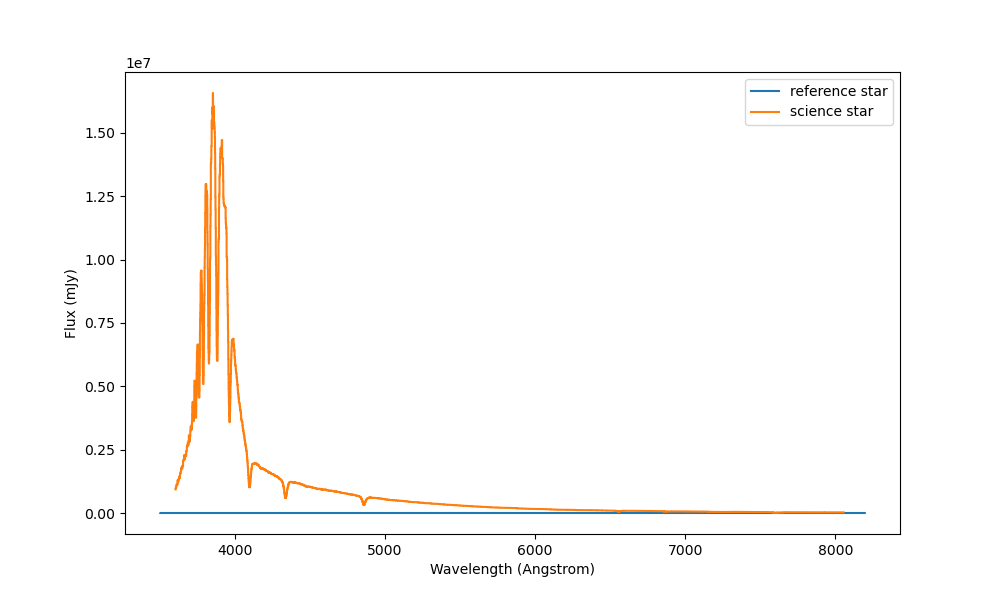

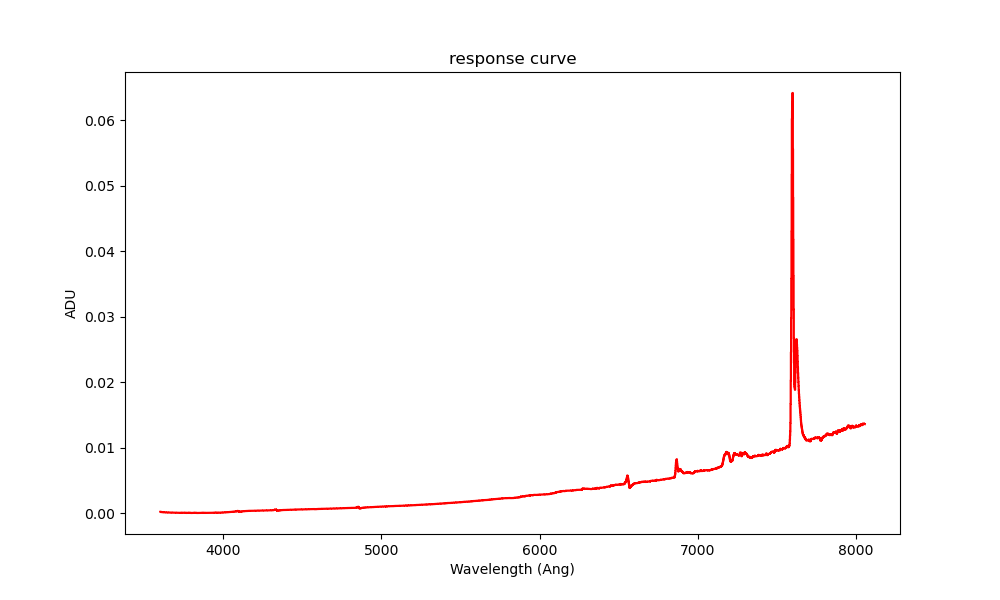

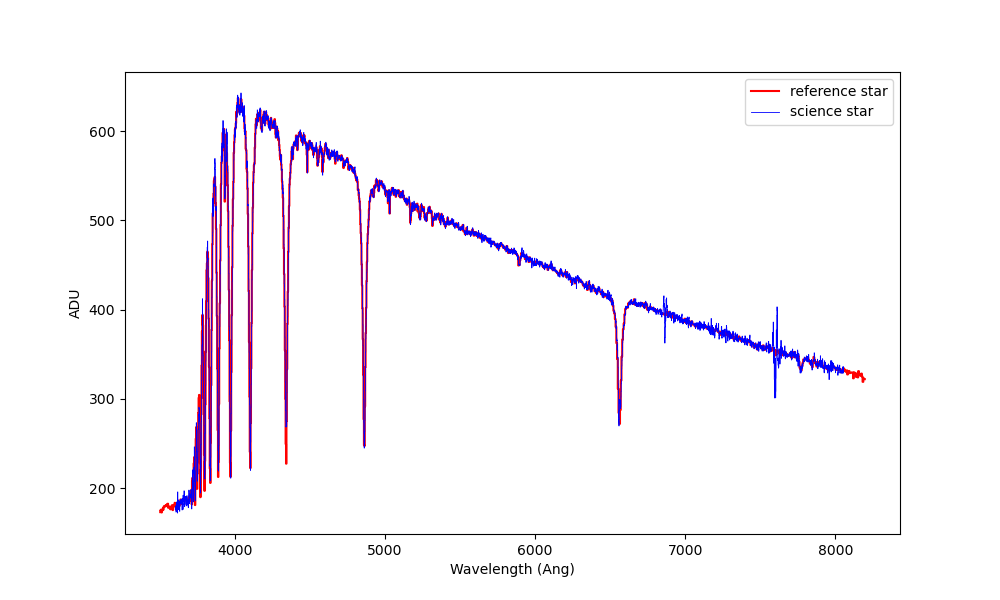

In [25]:
###
### version specreduce : création d'une réponse à partir d'un spectre de référence
###

#std_spec = load_onedstds(dataset = 'spec50cal', specfile = 'hd217086.dat')
#std_spec = load_onedstds(dataset = 'bstdscal', specfile = 'hr5511.dat')
#std_spec = load_MAST_calspec("delumi_stis_004.fits")
#std_spec = load_MAST_calspec("bd60d1753_stiswfc_004.fits")
#std_spec = load_MAST_calspec("hd93521_stis_007.fits")         # O9Vp
#std_spec = load_MAST_calspec("hd101452_stis_004.fits")        # A2/3
#std_spec = load_MAST_calspec('etauma_stis_008.fits') # B3V
#REFERENCE_STAR = 'data/MilesLibraryBASS/A1IV s0796 HD204041.dat'
REFERENCE_STAR = 'bd60d1753_stiswfc_004.fits'

# on charge le spectre
# méthode avec specreduce
std_spec = load_MAST_calspec(REFERENCE_STAR)
std_spec = std_spec[3500*u.AA:8200*u.AA]


"""
# méthode avec des .DAT
_spc_array = np.loadtxt(REFERENCE_STAR)

# on normalise
mask_ref = (NORM_RANGE[0] <= _spc_array[:, 0]) & (_spc_array[:, 0] <= NORM_RANGE[1])
mean_intensity = np.mean(_spc_array[mask_ref, 1])
_spc_array[:, 1] /= mean_intensity

std_spec = Spectrum(spectral_axis=_spc_array[:,0] * u.Unit('Angstrom'), flux=_spc_array[:,1] * u.Unit('adu'))
dash.clear_spectra()
dash.show_spectrum(std_spec.spectral_axis, std_spec.flux, label='ref')

# on normalise aussi le spectre extrait
mask = (science_calibrated_spectrum.spectral_axis >= NORM_RANGE[0]*u.AA) & (science_calibrated_spectrum.spectral_axis <= NORM_RANGE[1]*u.AA)
mean_flux = np.mean(science_calibrated_spectrum.flux[mask])
normalized_flux = science_calibrated_spectrum.flux / mean_flux
sci_slice = Spectrum(spectral_axis=science_calibrated_spectrum.spectral_axis, flux=normalized_flux)

dash.clear_spectra()
dash.show_spectrum(sci_slice.spectral_axis, sci_slice.flux, label='science')

# on ré-echatillonne la ref
resampler = FluxConservingResampler(extrapolation_treatment='truncate')
std_slice = resampler(std_spec, sci_slice.spectral_axis)

# on ré-echatillonne la science
sci_slice = resampler(sci_slice, std_slice.spectral_axis)
"""

sci_slice = Spectrum(spectral_axis=science_calibrated_spectrum.spectral_axis, flux=science_calibrated_spectrum.flux)
std_slice = Spectrum(spectral_axis=std_spec.spectral_axis, flux=std_spec.flux)


### show both spectra
fig, ax = plt.subplots(figsize=(10,6))
#plt.xlim(WAVE_RANGE)     
ax.step(std_slice.spectral_axis, std_slice.flux, label = 'reference star') #, where="mid"
ax.step(sci_slice.spectral_axis, sci_slice.flux, label = 'science star') # where="mid", 
ax.set_xlabel(f"Wavelength ({std_slice.spectral_axis.unit})")
ax.set_ylabel(f"Flux ({std_slice.flux.unit})");
plt.legend(loc=('best'))

obj_spectrum = sci_slice
std_spectrum = std_slice

fcal = FluxCalibration() 
fcal(airmass=airmass, object_spectrum=obj_spectrum)
                
### reuse response file if exists
#if False:
if os.path.exists(CAPTURE_DIR + OUTPUT_RESPONSE):
#if False:
    print('reusing existing response file ... ')
    with fits.open(CAPTURE_DIR + OUTPUT_RESPONSE) as resp:
        specdata = resp[1].data
        header = resp[1].header
        responsefunc = Spectrum(flux = specdata['flux']* u.mJy, spectral_axis = specdata['wavelength'] * u.AA)
        
        final_spec = fcal.apply_sensfunc(responsefunc)
 
    print('response applied')
else:
    print('creating a new response file ...')
    responsefunc = fcal.standard_sensfunc(
    #responsefunc = sci_spectrum.standard_sensfunc(
        standard = std_spectrum,
        mode = 'linear', # 'linear', #'linear', # 'poly', #'spline', 
        #polydeg = 5,
        #badlines=[6868, 7612, 7516, 6880, 6844, 6860, 6920, 6563, 6566, 4861, 4341],
        #badlines=[6868],
        display = False)
    print('response created')

    ### filter the response func
    #smooth_response = gaussian_smooth(responsefunc, stddev=3) 
    #smooth_response = median_smooth(responsefunc, width=55) #2055) 
    #responsefunc = smooth_response
    print('response median smoothed')
        
    final_spec = fcal.apply_sensfunc(responsefunc)
    #final_spec = sci_spectrum.apply_sensfunc(responsefunc)
    #final_spec = obj_spectrum / std_spectrum

    print('response applied')

    responsefunc.write(CAPTURE_DIR + OUTPUT_RESPONSE, overwrite = True)

plt.figure(figsize=(10,6))
#plt.xlim(WAVE_RANGE)    

plt.xlabel('Wavelength (Ang)')
plt.ylabel('ADU')
plt.step(responsefunc.wavelength, responsefunc.flux, linewidth = '1.6', color = 'r');
plt.title('response curve')


plt.figure(figsize=(10,6))
plt.xlabel('Wavelength (Ang)')
plt.ylabel('ADU')
#plt.step(obj_spectrum.wavelength, obj_spectrum.flux, linewidth = '0.6', color = 'black');
plt.step(std_slice.wavelength, std_slice.flux, color = 'r', label = 'reference star') #, where="mid", 
plt.step(final_spec.wavelength, final_spec.flux, linewidth = '0.6', color = 'b', label = 'science star'); #, where="mid",
plt.legend(loc=('best'))
#plt.step(std_spec.wavelength, std_spec.flux + 5000 * u.mJy, linewidth = '0.6', color = 'r')
#plt.ylim(-10000, 1e6)

#show_lines(ax = None, show_line = True)

# cropping, normalisation et sauvegarde

In [23]:
#
# on normalize à 1 autour de 6000 AA

sci_mean_norm_region = final_spec[4950 * u.AA: 5000 * u.AA].flux.mean()        # DADOS200 : low resolution
#sci_mean_norm_region = final_spec[6500 * u.AA: 6520 * u.AA].flux.mean()       # starEx2400 : high resolution

#final_spec = np.nan_to_num(final_spec, nan=1)
lambda_crop_min = 3700*u.AA
lambda_crop_max = 7100*u.AA

print(f"{sci_mean_norm_region=}")
_spec = Spectrum(spectral_axis = final_spec[lambda_crop_min:lambda_crop_max].wavelength, flux = final_spec[lambda_crop_min:lambda_crop_max].flux / sci_mean_norm_region)  

# n applique un décalage si besoin
#SHIFT_WAVE = 0 * u.AA
#_spec = Spectrum(spectral_axis = _spec.wavelength + SHIFT_WAVE, flux = _spec.flux)  

# on sauve le spectre eu format FITS
_spec.write(CAPTURE_DIR + 'spectre-1D.fit', overwrite=True) #, format='tabular-fits')


### on sauve au format ASCII pour fityk ou Excel
np.savetxt(CAPTURE_DIR + 'spectre-1D-tabular.dat', 
           np.array([_spec.spectral_axis.value, _spec.flux.value]).T, 
           fmt='%.8f', 
           header='WAVELENGTH FLUX')

dash.clear_spectra()
dash.show_spectrum(_spec.spectral_axis, _spec.flux, label='response applied')
dash.ax_spec.set_ylim(min(_spec.flux.data), max(_spec.flux.data))


sci_mean_norm_region=<Quantity 539.47721488 mJy>
INFO: affichage du spectre 'response applied' : 2970 pts, X:[3700.9:7098.8]


(0.32757428387714205, 1.1914194826415403)

# affichage final

In [24]:
#%matplotlib widget
#import numpy as np
#from spectro_dashboard import SpectroDashboard

#dash = SpectroDashboard()
#dash.show()

spc = Spectrum.read(CAPTURE_DIR + 'spectre-1D-tabular.dat', ignore_missing_simple=True, format='ASCII',  
                    column_mapping = {'FLUX': ('flux', 'adu'), 'WAVELENGTH': ('spectral_axis', 'AA')})

#specinti_spec = Spectrum.read(CAPTURE_DIR + '_ruchbah_20250807_916.fit')
#specinti_spec = Spectrum.read(CAPTURE_DIR + '_gamcas_20250807_912.fit')
#specinti_spec = Spectrum.read(CAPTURE_DIR + '_lamcyg_20251102_914.fits')
#specinti_spec = Spectrum.read(CAPTURE_DIR + '_v1770cyg_20251102_906.fits')

lambda_crop_min = 3800*u.AA
lambda_crop_max = 7300*u.AA

print (min(spc.flux), max(spc.flux))

dash.clear_spectra()
dash.show_image(master_science, name=master_science.meta['OBJECT'])
dash.show_spectrum(spc[lambda_crop_min:lambda_crop_max].wavelength, spc[lambda_crop_min:lambda_crop_max].flux, label="final")
#dash.show_spectrum(specinti_spec[lambda_crop_min:lambda_crop_max].wavelength, specinti_spec[lambda_crop_min:lambda_crop_max].flux, label="specinti")
dash.ax_spec.set_ylim(min(spc.flux.data), max(spc.flux.data))

#dash.ax_spec.set_ylim(min(spc.flux), max(spc.flux))

#dash.show_spectrum(specinti_spec[3800*u.AA:7300*u.AA].wavelength, specinti_spec[3800*u.AA:7300*u.AA].flux, label="specinti")


0.32757428 adu 1.19141948 adu
INFO: affichage de l'image merak : bin=1, shape=(550, 3856), min=-216334780805611, avg=-102003087.4, max=1668776, stddev=148551276539.9
INFO: affichage du spectre 'final' : 2880 pts, X:[3800.1:7098.8]


(0.32757428, 1.19141948)